# Classes and Functions

## Wrapper

In [32]:
import numpy as np
from torch.nn.utils import clip_grad_norm_
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import accuracy_score

# Scikit Lean wrapper
class MyWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model, classes:list | np.ndarray, lr:float=1e-3, epochs:int=50, batch_size:int=None, device:torch.device=None, is_fitted:bool = False):
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        self.model = model.to(self.device)
        self.classes = classes
        self.classes_ = classes

        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.is_fitted  = is_fitted


    def fit(self, X: np.ndarray, y: np.ndarray, sample_weight=None) -> float:
        def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
            model.train()
            running_loss = 0.0
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                running_loss += loss.item()
                loss.backward()
                clip_grad_norm_(model.parameters(), max_norm=max_norm)
                optimizer.step()
            avg_loss = running_loss / len(loader)

            return avg_loss

        self.model.to(self.device)
        optimzer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        if len(self.classes) == 2:
            criterion = nn.BCEWithLogitsLoss()
            y_tensor = torch.Tensor(y).to(self.device)

        else:
            criterion = nn.CrossEntropyLoss()
            y_tensor = torch.Tensor(y).long().to(self.device)

        X_tensor = torch.Tensor(X).to(self.device)

        if sample_weight is not None:
            sampler = WeightedRandomSampler(sample_weight, len(X_tensor), replacement=True)
        else:
            sampler = None

        train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=self.batch_size, sampler=sampler)

        running_loss = 0.0
        for epoch in range(self.epochs):
            running_loss += _train_one_epoch(self.model, train_loader, optimzer, criterion)

        print(f'Avrage Loss {running_loss/self.epochs}')

        self.is_fitted = True
        return self


    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_tensor = torch.Tensor(X).to(self.device)

        self.model.eval()
        output = self.model(X_tensor)

        if len(self.classes) == 2:
            proba = torch.sigmoid(output).detach().cpu().numpy()
            proba = proba.reshape(-1, 1)
            proba = np.hstack([1 - proba, proba])
        else:
            proba = torch.softmax(output, dim=1).detach().cpu().numpy()


        return proba

    def predict(self, X: np.ndarray) -> np.ndarray:
        proba = self.predict_proba(X)

        if len(self.classes) == 2:
            preds = self.classes[(proba[:, 1] >= 0.5).astype(int)]
        else:
            preds = self.classes[proba.argmax(axis=1)]

        return preds


    def score(self, X, y, sample_weight=None):
        check_is_fitted(self, attributes=["is_fitted"])
        y_pred = self.predict(X)

        return accuracy_score(y, y_pred, sample_weight=sample_weight)


## Model

In [7]:
# Network
from torch import nn
from typing import Literal

class MLPClassifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, input_dim:int, output_dim:int):
        super(MLPClassifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)


        self.activation = nn.ReLU()

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x.squeeze(1) if x.shape[-1] == 1 else x

## Classification Report and Calibration Plots

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, classification_report, confusion_matrix
import numpy as np
import warnings
from sklearn.calibration import calibration_curve

# Suppress all FutureWarnings
warnings.filterwarnings("ignore")


def report(model:MyWrapper, X: np.ndarray, target: np.ndarray, classes: list):
    """
    Generates a classification report, confusion matrix, and ROC curves
    by generating predictions directly from the provided model and features.
    """
    # Generate predictions inside the function
    y_proba = model.predict_proba(X)
    y_pred = model.predict(X)

    fig, ax = plt.subplots(1, 2, figsize=(20, 6))
    ax = ax.flatten()

    # 1. Confusion Matrix
    cf_mtx = confusion_matrix(target, y_pred)
    sns.heatmap(cf_mtx, annot=True, fmt="g", ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xticklabels(classes)
    ax[0].set_yticklabels(classes)

    # 2. Multiclass ROC Curve (One-vs-Rest)
    for idx in range(len(classes)):
        fpr, tpr, thresholds = roc_curve(target == idx, y_proba[:, idx])
        roc_auc = auc(fpr, tpr)
        display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
        display.plot(ax=ax[1])

    ax[1].plot([0, 1], [0, 1], color='white', linestyle='--')
    ax[1].set_title('Multiclass ROC Curve (One-vs-Rest)')

    plt.legend(classes)
    plt.show()

    # 3. Text Classification Report
    clf_r = classification_report(target, y_pred, target_names=[str(c) for c in classes])
    print(clf_r)

def plot_calibration_curve(
    X: np.ndarray,
    y_true: np.ndarray,
    model,
    classes: list,
    n_bins: int = 10
):
    """
    Generates probability predictions internally using a single model wrapper
    and creates a standalone One-vs-Rest calibration plot.

    Parameters:
    -----------
    X : np.ndarray
        Input features used for making predictions.
    y_true : np.ndarray
        True target labels.
    model :
        The model wrapper implementing .predict_proba() (e.g., your MyWrapper or CalibratedClassifierCV).
    classes : list
        List of class names/identifiers matching the class indices.
    n_bins : int, default=10
        Number of bins for the calibration curve.
    """
    n_classes = len(classes)

    # Generate predictions inside the function using the wrapper
    probs = model.predict_proba(X)

    plt.figure(figsize=(8, 6))

    # Plot the ideal 45-degree perfect calibration line
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.7, label="Perfectly calibrated")

    # Compute and plot the One-vs-Rest curve for each class
    for idx in range(n_classes):
        y_true_binary = (y_true == idx).astype(int)
        y_prob_class = probs[:, idx]

        prob_true, prob_pred = calibration_curve(
            y_true_binary, y_prob_class, n_bins=n_bins, strategy="uniform"
        )

        plt.plot(prob_pred, prob_true, marker="o", label=f"{classes[idx]}")

    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives (Actual)")
    plt.title("Model Calibration Curves (One-vs-Rest)")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()

def compare_calibration_curves(
    X: np.ndarray,
    y_true: np.ndarray,
    model_1,
    model_2,
    classes: list,
    model_1_name: str = "Model 1",
    model_2_name: str = "Model 2",
    n_bins: int = 10
):
    """
    Generates probability predictions internally for two models and plots
    their One-vs-Rest calibration curves side-by-side.

    Parameters:
    -----------
    X : np.ndarray
        Input features used for making predictions.
    y_true : np.ndarray
        True target labels.
    model_1 :
        The first model wrapper implementing .predict_proba().
    model_2 :
        The second model wrapper implementing .predict_proba().
    classes : list
        List of class names/identifiers matching the class indices.
    model_1_name : str, default="Model 1"
        Name/Title for the first plot.
    model_2_name : str, default="Model 2"
        Name/Title for the second plot.
    n_bins : int, default=10
        Number of bins for the calibration curve.
    """
    n_classes = len(classes)

    # Generate predictions inside the function for both models
    probs_1 = model_1.predict_proba(X)
    probs_2 = model_2.predict_proba(X)

    # Create a 1x2 subplot figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    plot_configs = [
        {"probs": probs_1, "ax": axes[0], "title": f"{model_1_name} Calibration"},
        {"probs": probs_2, "ax": axes[1], "title": f"{model_2_name} Calibration"}
    ]

    for config in plot_configs:
        ax = config["ax"]
        probs = config["probs"]

        # Plot ideal reference line
        ax.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.7, label="Perfectly calibrated")

        # Compute and plot OvR curve for each class
        for idx in range(n_classes):
            y_true_binary = (y_true == idx).astype(int)
            y_prob_class = probs[:, idx]

            prob_true, prob_pred = calibration_curve(
                y_true_binary, y_prob_class, n_bins=n_bins, strategy="uniform"
            )

            ax.plot(prob_pred, prob_true, marker="o", label=f"{classes[idx]}")

        ax.set_xlabel("Mean Predicted Probability")
        ax.set_ylabel("Fraction of Positives (Actual)")
        ax.set_title(config["title"])
        ax.legend(loc="lower right")
        ax.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

# Data

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os


path = os.path.join('Data', 'cal.csv')
data = pd.read_csv(path)

target_name = 'NObeyesdad'
X, y = data.drop([target_name], axis=1), data[target_name]
X_cal, X_test, y_cal, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Calibration set: {len(y_cal)}')
print(f'Calibration check set: {len(y_cal)}')

Calibration set: 2657
Calibration check set: 2657


In [17]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os


path = os.path.join('Data', 'train.csv')
data = pd.read_csv(path)

target_name = 'NObeyesdad'
X, y = data.drop([target_name], axis=1), data[target_name]

print(f'Trian, Val and Test data size: {len(y)}')

Trian, Val and Test data size: 13284


# Model and Classifcation report

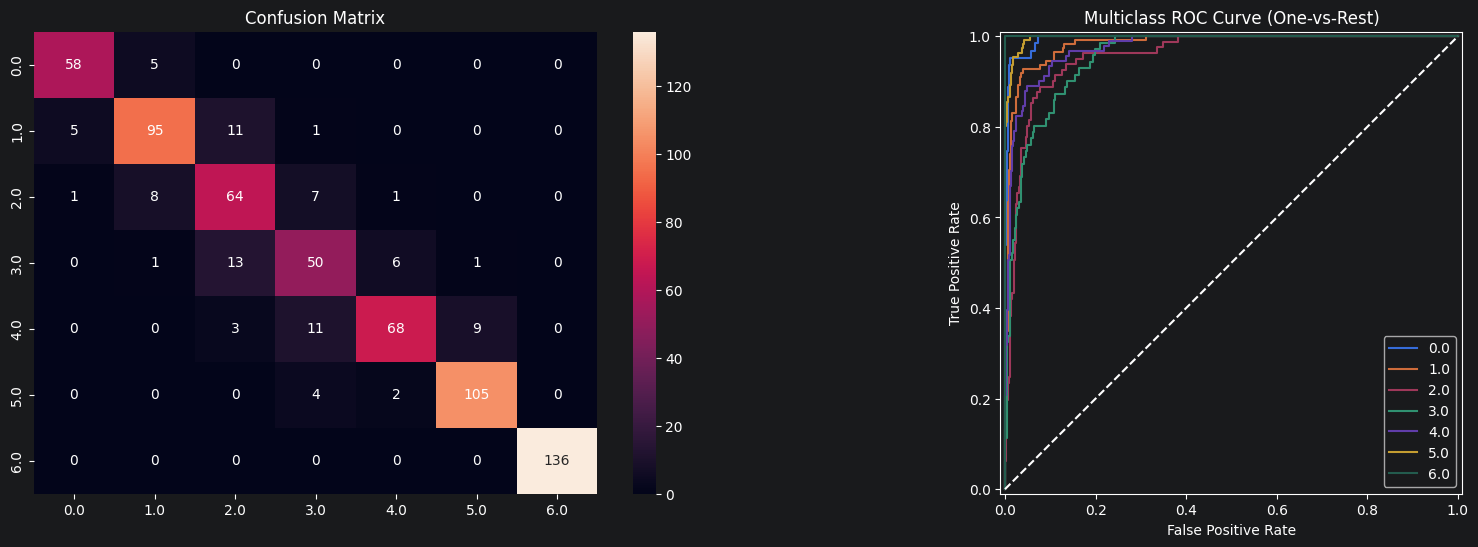

              precision    recall  f1-score   support

         0.0       0.91      0.92      0.91        63
         1.0       0.87      0.85      0.86       112
         2.0       0.70      0.79      0.74        81
         3.0       0.68      0.70      0.69        71
         4.0       0.88      0.75      0.81        91
         5.0       0.91      0.95      0.93       111
         6.0       1.00      1.00      1.00       136

    accuracy                           0.87       665
   macro avg       0.85      0.85      0.85       665
weighted avg       0.87      0.87      0.87       665



In [39]:
model_path = os.path.join('Models', 'NotCalibrated', 'last.ckpt')
checkpoint = torch.load(model_path, map_location=lambda storage, loc: storage)

X_cal_np = X_cal.to_numpy()
y_cal_np = y_cal.to_numpy()
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

model_config = checkpoint["hyper_parameters"]
model_config.pop('lr')

raw_state_dict = checkpoint['state_dict']
clean_state_dict = {k.replace('model.', ''): v for k, v in raw_state_dict.items()}

model = MLPClassifier(**model_config)
model.load_state_dict(clean_state_dict)

sorted_classes = np.sort(y_cal.unique())
wrappedModel = MyWrapper(model, classes=sorted_classes, is_fitted=True, device=torch.device('cpu'))
report(wrappedModel, X_test_np, y_test_np, classes=sorted_classes)

# Calibration

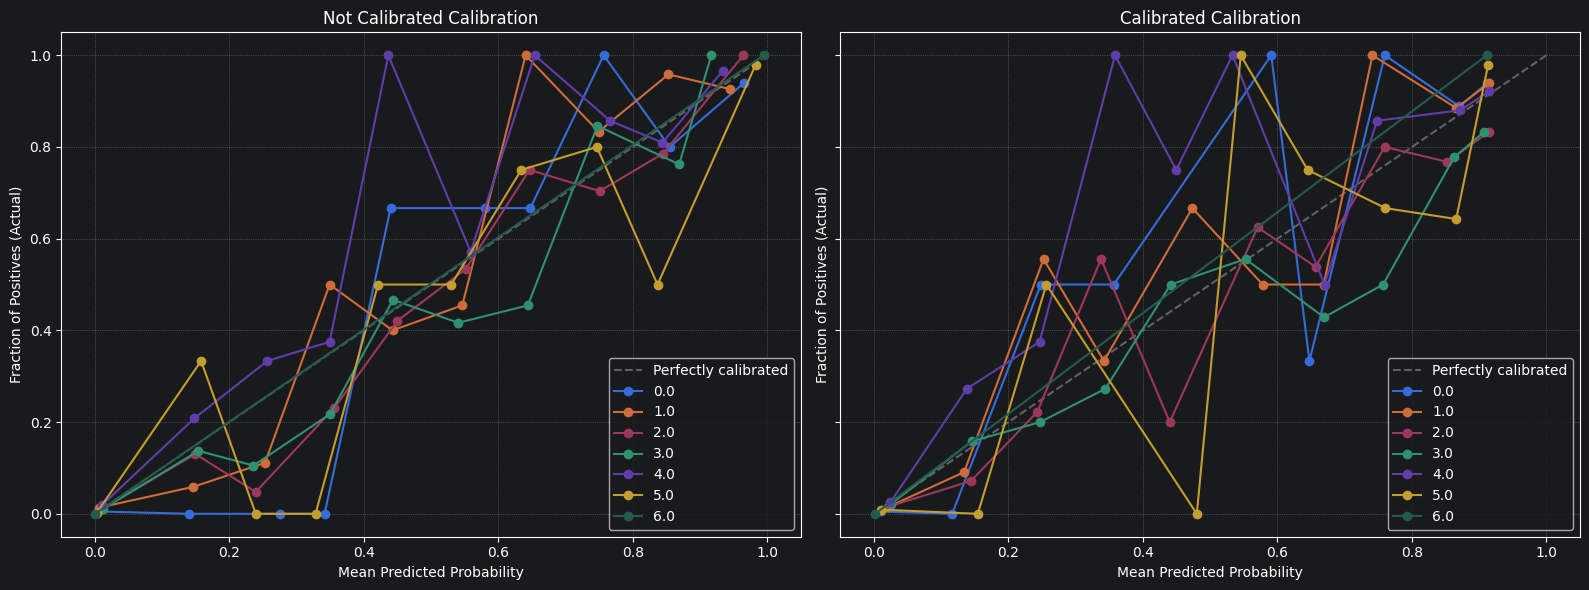

In [49]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_clf = CalibratedClassifierCV(wrappedModel, method='sigmoid', cv = 'prefit')
calibrated_clf.fit(X_cal_np, y_cal_np)

compare_calibration_curves(X=X_test_np,
                           y_true=y_test_np,
                           model_1=wrappedModel,
                           model_2=calibrated_clf,
                           model_1_name='Not Calibrated',
                           model_2_name='Calibrated',
                           classes=sorted_classes)

## Calibrated Classifier Sanity Check

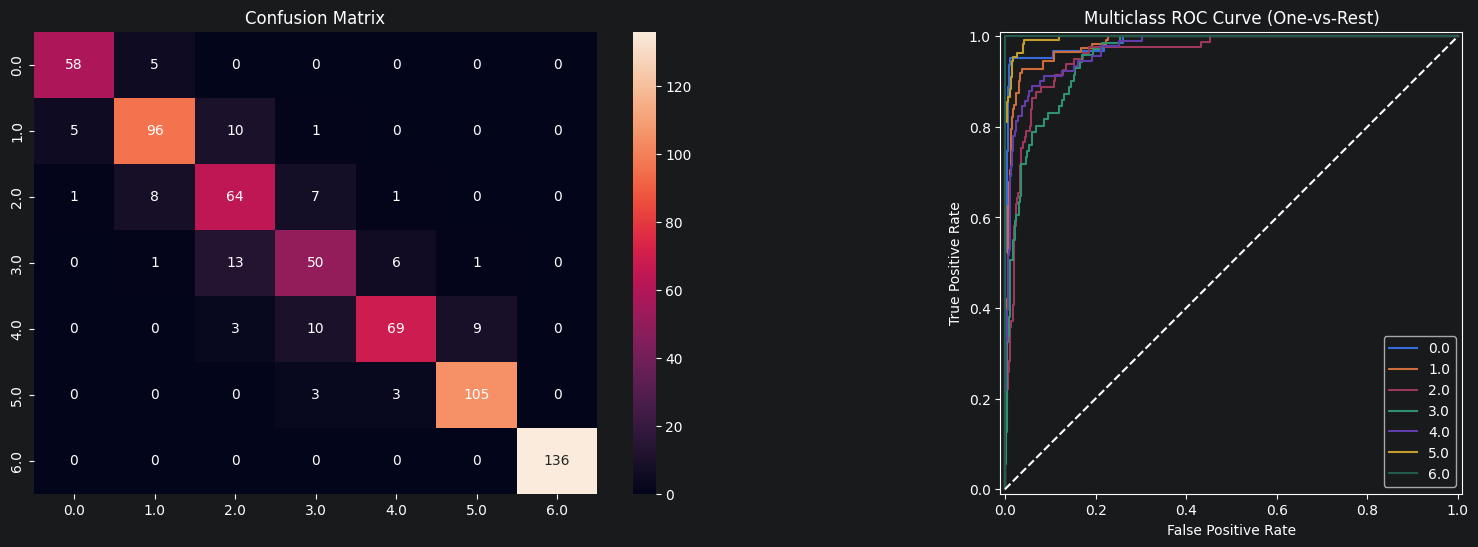

              precision    recall  f1-score   support

         0.0       0.91      0.92      0.91        63
         1.0       0.87      0.86      0.86       112
         2.0       0.71      0.79      0.75        81
         3.0       0.70      0.70      0.70        71
         4.0       0.87      0.76      0.81        91
         5.0       0.91      0.95      0.93       111
         6.0       1.00      1.00      1.00       136

    accuracy                           0.87       665
   macro avg       0.85      0.85      0.85       665
weighted avg       0.87      0.87      0.87       665



In [50]:
report(calibrated_clf, X_test_np, y_test_np, classes=sorted_classes)

# Uncertainty

## Function

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_prediction_uncertainty(X: np.ndarray, y_true: np.ndarray, model, classes: list, top_n: int = 5):
    """
    Analizuje niepewność predykcji modelu, rysuje histogramy oraz wybiera
    przypadki najbardziej pewne i najbardziej niepewne.
    """
    # 1. Generowanie prawdopodobieństw za pomocą wrappera
    y_proba = model.predict_proba(X)
    y_pred = model.predict(X)

    # 2. Obliczenie miar pewności/niepewności
    # Maksymalne prawdopodobieństwo (im wyższe, tym model jest pewniejszy)
    max_probs = np.max(y_proba, axis=1)

    # Entropia Shannona (im wyższa, tym większa niepewność/czysty przypadek)
    # Dodajemy małą stałą (1e-9), aby uniknąć log(0)
    entropy = -np.sum(y_proba * np.log2(y_proba + 1e-9), axis=1)

    # Stworzenie DataFrame do łatwego zarządzania danymi
    df_res = pd.DataFrame({
        'Index': np.arange(len(X)),
        'True_Class': [classes[int(i)] for i in y_true],
        'Pred_Class': [classes[int(i)] for i in y_pred],
        'Confidence': max_probs,
        'Entropy': entropy,
        'Is_Correct': (y_true == y_pred)
    })

    # --- 3. WIZUALIZACJA ROZKŁADU NIEPEWNOŚCI ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    # Histogram maksymalnego prawdopodobieństwa
    sns.histplot(df_res['Confidence'], bins=20, kde=True, ax=ax[0], color='skyblue')
    ax[0].set_title('Rozkład Maksymalnego Prawdopodobieństwa (Confidence)')
    ax[0].set_xlabel('Pewność (Max Probability)')
    ax[0].set_ylabel('Liczba próbek')

    # Histogram entropii
    sns.histplot(df_res['Entropy'], bins=20, kde=True, ax=ax[1], color='salmon')
    ax[1].set_title('Rozkład Entropii (Miara Niepewności)')
    ax[1].set_xlabel('Entropia (Większa = większa niepewność)')
    ax[1].set_ylabel('Liczba próbek')

    plt.tight_layout()
    plt.show()

    # --- 4. SELEKCJA PRZYPADKÓW ---
    # Najbardziej pewne: niska entropia i wysokie prawdopodobieństwo
    most_confident = df_res.sort_values(by='Confidence', ascending=False).head(top_n)

    # Najbardziej niepewne: wysoka entropia (rozkład bliski jednostajnemu)
    least_confident = df_res.sort_values(by='Entropy', ascending=False).head(top_n)

    print(f"=== TOP {top_n} NAJBARDZIEJ PEWNYCH PRZYPADKÓW ===")
    print(most_confident.to_string(index=False))
    print("\n" + "="*50 + "\n")
    print(f"=== TOP {top_n} NAJBARDZIEJ NIEPEWNYCH PRZYPADKÓW ===")
    print(least_confident.to_string(index=False))

    return most_confident, least_confident

In [72]:
import numpy as np
import torch

def calculate_uncertainties_multiclass(probs):
    """
    Calculate uncertainty measures for single-model multiclass predictions.

    Parameters:
    -----------
    probs : np.ndarray, shape (n_samples, n_classes)
        Predicted probability distributions from a single model

    Returns:
    --------
    total_uncertainty : np.ndarray, shape (n_samples,)
        Shannon entropy - how "spread out" is the probability distribution
        High entropy = uncertain, Low entropy = confident

    epistemic_uncertainty : np.ndarray, shape (n_samples,)
        Confidence measure - distance from uniform distribution
        High = model is NOT very confident in any class

    aleatoric_uncertainty : np.ndarray, shape (n_samples,)
        Variation ratio - probability NOT in the top class
        High = second-best class has significant probability

    References:
    -----------
    Shannon entropy: H(p) = -Σ p_i * log(p_i)
    Variation ratio: VR = 1 - max(p_i)
    """

    eps = 1e-12
    probs = np.clip(probs, eps, 1.0 - eps)

    n_samples, n_classes = probs.shape

    # 1. TOTAL UNCERTAINTY: Shannon entropy
    # Measures how "spread out" the probability distribution is
    # Range: [0, log(n_classes)]. For 4 classes: [0, 2]
    total_uncertainty = -np.sum(probs * np.log2(probs), axis=1)

    # 2. EPISTEMIC UNCERTAINTY: Confidence-based measure
    # How far is the model from being confident (max_prob = 1.0)?
    max_prob = np.max(probs, axis=1)
    # Convert to uncertainty scale: 0 when max_prob=1 (confident),
    # increases as max_prob decreases
    epistemic_uncertainty = -np.log2(max_prob)

    # 3. ALEATORIC UNCERTAINTY: Variation ratio
    # What fraction of probability is NOT in the predicted class?
    # This captures: if we re-sampled from this distribution, would we get the same prediction?
    aleatoric_uncertainty = 1.0 - max_prob

    return total_uncertainty, epistemic_uncertainty, aleatoric_uncertainty


## Most and Least Confident Cases

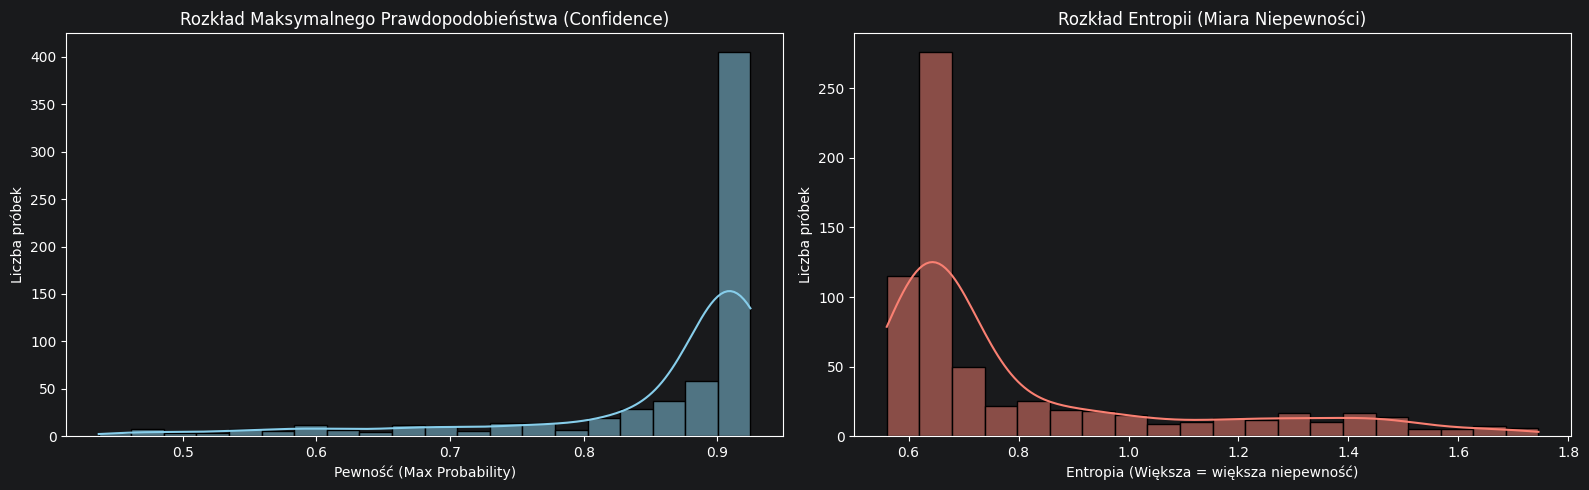

=== TOP 5 NAJBARDZIEJ PEWNYCH PRZYPADKÓW ===
 Index  True_Class  Pred_Class  Confidence  Entropy  Is_Correct
   104         4.0         4.0    0.924647 0.560324        True
   653         4.0         4.0    0.923047 0.569553        True
   249         1.0         1.0    0.922407 0.573949        True
   489         4.0         4.0    0.922335 0.573307        True
   329         1.0         1.0    0.921767 0.577082        True


=== TOP 5 NAJBARDZIEJ NIEPEWNYCH PRZYPADKÓW ===
 Index  True_Class  Pred_Class  Confidence  Entropy  Is_Correct
   188         3.0         3.0    0.524432 1.745608        True
    38         2.0         2.0    0.540589 1.731913        True
   535         4.0         4.0    0.441190 1.731119        True
   284         5.0         5.0    0.545497 1.729354        True
    27         5.0         4.0    0.449051 1.707389       False


In [64]:
most_conf, least_conf = analyze_prediction_uncertainty(
    X=X_test_np,
    y_true=y_test_np,
    model=calibrated_clf,
    classes=sorted_classes,
    top_n=5
)

## Overall Aletoric and Epistemic Uncertanity

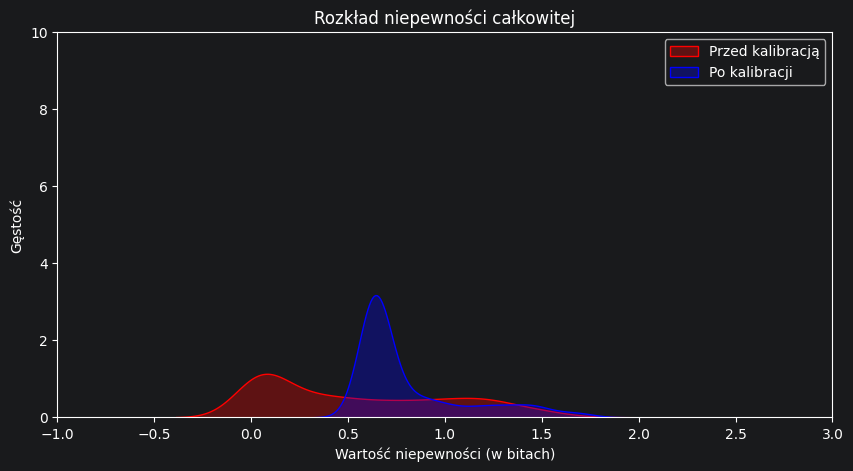

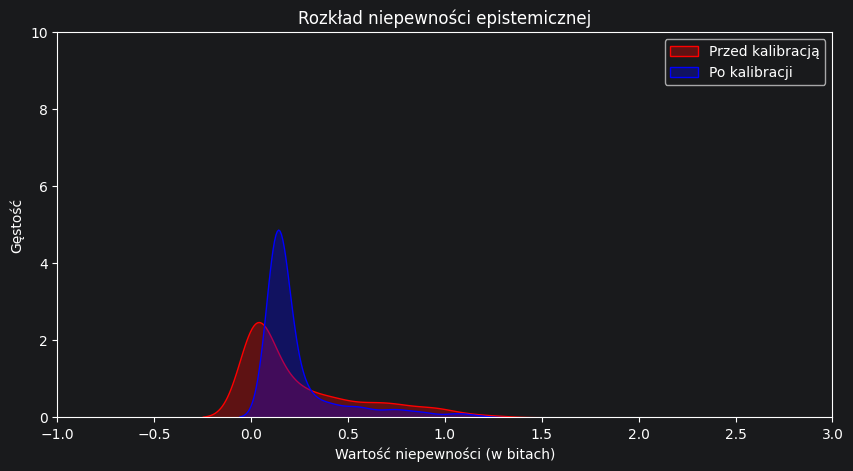

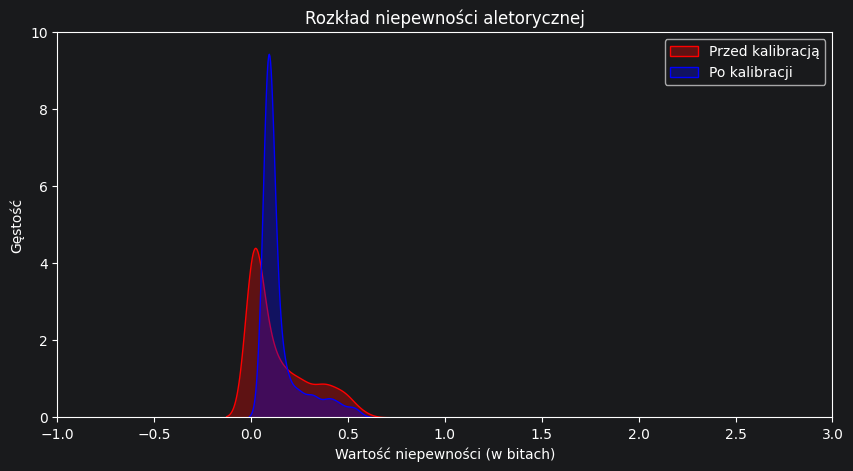

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

after_prob = wrappedModel.predict_proba(X_test_np)
before_prob = calibrated_clf.predict_proba(X_test_np)

total_bef, epistemic_bef, aleatoric_bef = calculate_uncertainties_multiclass(after_prob)
total_aft, epistemic_aft, aleatoric_aft = calculate_uncertainties_multiclass(before_prob)


plt.figure(figsize=(10, 5))
sns.kdeplot(total_bef, label="Przed kalibracją", color="red", fill=True, alpha=0.3)
sns.kdeplot(total_aft, label="Po kalibracji", color="blue", fill=True, alpha=0.3)
plt.title("Rozkład niepewności całkowitej")
plt.xlabel("Wartość niepewności (w bitach)")
plt.xlim([-1,3])
plt.ylim(0,10)
plt.ylabel("Gęstość")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(epistemic_bef, label="Przed kalibracją", color="red", fill=True, alpha=0.3)
sns.kdeplot(epistemic_aft, label="Po kalibracji", color="blue", fill=True, alpha=0.3)
plt.title("Rozkład niepewności epistemicznej")
plt.xlabel("Wartość niepewności (w bitach)")
plt.xlim([-1,3])
plt.ylim(0,10)
plt.ylabel("Gęstość")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(aleatoric_bef, label="Przed kalibracją", color="red", fill=True, alpha=0.3)
sns.kdeplot(aleatoric_aft, label="Po kalibracji", color="blue", fill=True, alpha=0.3)
plt.title("Rozkład niepewności aletorycznej")
plt.xlabel("Wartość niepewności (w bitach)")
plt.xlim([-1,3])
plt.ylim(0,10)
plt.ylabel("Gęstość")
plt.legend()
plt.show()